# Intro

* The equation, implementation, and interpretation of cosine similarity
* How cosine similarity is related to Pearson correlation coefficient

Motivations:

* Token-pair embeddings
* Model weights matrices
* Attention-layer activations
* Residual stream updates

Cosine similarity is a normalized measure of bivariate linear relationships

Max Cosine Similarity $\rightarrow S_c$ = 1

Similar variables $ \rightarrow S_c$ > 0

No relationship $\rightarrow S_c \sim 0$

Negative relationship $\rightarrow S_c <0$

Cosine Similarity

$$ cos(\theta) = \frac{\sum_{i=1}^n x_i y_i}{\sqrt{\sum_{i=1}^nx_i^2}\sqrt{\sum_{i=1}^ny_i^2}} $$

Pearson

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
import torch

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Cosine Similarity vs Pearson Correlation

## Generate some data

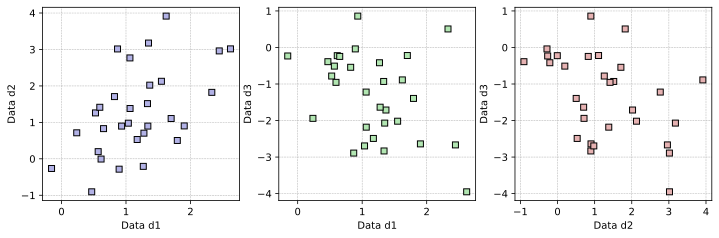

In [3]:
N = 30

# data vectors
d1 = np.random.randn(N) + 1  # add an offset for Pearson vs. cosine-similarity
d2 = d1 + np.random.randn(N)
d3 = -d1 + np.random.randn(N)

# visualize
_, axs = plt.subplots(1,3,figsize = (12, 3.5))
axs[0].plot(d1, d2, 'ks', markerfacecolor = [.7,.7,.9])
axs[0].set(xlabel = 'Data d1', ylabel = 'Data d2')

axs[1].plot(d1, d3, 'ks', markerfacecolor = [.7,.9,.7])
axs[1].set(xlabel = 'Data d1', ylabel = 'Data d3')

axs[2].plot(d2, d3, 'ks', markerfacecolor = [.9,.7,.7])
axs[2].set(xlabel = 'Data d2', ylabel = 'Data d3')

for a in axs: a.grid(linestyle = '--', linewidth = .5)

## Cosine similarity

In [10]:
# manual
num = sum(d1*d2)
den = sum(d1*d1)*sum(d2**2)
cossim_manual = num/np.sqrt(den)

print(f'Manual calc: {cossim_manual:.4f}')

Manual calc: 0.8201


In [8]:
# sklearn
cossim_sklearn = cosine_similarity(d1.reshape(1,-1),d2.reshape(1,-1))
print(f'Sci-kit learn: {cossim_sklearn[0][0]:.4f}')

Sci-kit learn: 0.8201


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
cossim_sklearn = cosine_similarity(d1.reshape(1, -1), d2.reshape(1, -1))
print(f'Sci-kit lean: {cossim_sklearn[0][0]:.4f}')

Sci-kit lean: 0.8201


## Pearson Corr

In [20]:
# mean-center
d1m = d1 - np.mean(d1)
d2m = d2 - np.mean(d2)

# manual calc
num = sum(d1m * d2m)
den = sum(d1m * d1m) * sum(d2m * d2m)
corr_manual = num / np.sqrt(den)

# numpy
corr_np = np.corrcoef(d1, d2)[0,1]

# cosine similarity using mean-centered data
cossimM_sklearn = cosine_similarity(d1m.reshape(1,-1), d2m.reshape(1,-1))

# print all the results
print(f'Manual calculation: Pearson correlation between d1 and d2 is {corr_manual:.4f}')
print(f'Numpy  corrcoef():  Pearson correlation between d1 and d2 is {corr_np:.4f}')
print('\n')
print(f'Sci-kit learn:      Cosine similarity between d1m and d2m is {cossimM_sklearn[0][0]:.4f}')
print(f'Sci-kit learn:      Cosine similarity between d1 and d2 is   {cossim_sklearn[0][0]:.4f}')

Manual calculation: Pearson correlation between d1 and d2 is 0.5241
Numpy  corrcoef():  Pearson correlation between d1 and d2 is 0.5241


Sci-kit learn:      Cosine similarity between d1m and d2m is 0.5241
Sci-kit learn:      Cosine similarity between d1 and d2 is   0.8201


Cosine Similarity between d1m and d2m is simply Pearson Correlation, i.e. Cosine Similarity and Pearson Correlation are exactly the same IF means of both vectors are 0.

## Cosine similarity in PyTorch

In [22]:
d1_t, d2_t = torch.tensor(d1), torch.tensor(d2)

In [29]:
torch.cosine_similarity(d1_t.reshape(1,-1), d2_t.reshape(1,-1))

tensor([0.8201], dtype=torch.float64)

## Back to Viz

/tmp/ipython-input-2831538634.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  d2 = torch.tensor(d1  + np.random.randn(N)).reshape(1,-1)
/tmp/ipython-input-2831538634.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d2 = torch.tensor(d1  + np.random.randn(N)).reshape(1,-1)
/tmp/ipython-input-2831538634.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  d3 = torch.tensor(-d1 + np.random.randn(N)).reshape(1,-1)
/tmp/ipython-input-2831538634.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d3 = torch

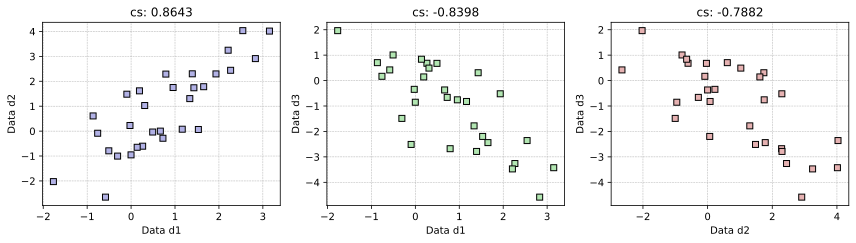

In [38]:
N = 30

# data vectors
d1 = torch.tensor(np.random.randn(N) + 1).reshape(1,-1)  # add an offset for Pearson vs. cosine-similarity
d2 = torch.tensor(d1  + np.random.randn(N)).reshape(1,-1)
d3 = torch.tensor(-d1 + np.random.randn(N)).reshape(1,-1)

cs_d12 = torch.cosine_similarity(d1, d2).item()
cs_d23 = torch.cosine_similarity(d2, d3).item()
cs_d13 = torch.cosine_similarity(d1, d3).item()

# visualize
_, axs = plt.subplots(1,3,figsize = (12, 3.5))
axs[0].plot(d1, d2, 'ks', markerfacecolor = [.7,.7,.9])
axs[0].set(xlabel = 'Data d1', ylabel = 'Data d2', title = f'cs: {cs_d12:.4f}')

axs[1].plot(d1, d3, 'ks', markerfacecolor = [.7,.9,.7])
axs[1].set(xlabel = 'Data d1', ylabel = 'Data d3', title = f'cs: {cs_d13:.4f}')

axs[2].plot(d2, d3, 'ks', markerfacecolor = [.9,.7,.7])
axs[2].set(xlabel = 'Data d2', ylabel = 'Data d3', title = f'cs: {cs_d23:.4f}')

for a in axs: a.grid(linestyle = '--', linewidth = .5)

plt.tight_layout()
plt.show()

# GPT2 Cosine Similarities

* Some of the challenges with cosine similarity in multitoken words
* How to use cosine similarity to identify similar tokens
* How to calculate cosine similarity efficiently using matrix multiplication

In [3]:
from transformers import GPT2Model, GPT2Tokenizer
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

gpt2_tokenizer  = GPT2Tokenizer.from_pretrained('gpt2')
gpt2 = GPT2Model.from_pretrained('gpt2')
gpt2_embeddings = gpt2.wte.weight.detach().numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Words

In [4]:
word1 = 'banana'
word2 = 'apple'
word3 = 'cosmic'

# decomposition
for w in [word1, word2, word3]:
  t = gpt2_tokenizer.encode(w)
  print(f'"{w}" comprises {len(t)} tokens:\n   {[gpt2_tokenizer.decode(i) for i in t]}\n')

"banana" comprises 2 tokens:
   ['ban', 'ana']

"apple" comprises 1 tokens:
   ['apple']

"cosmic" comprises 2 tokens:
   ['cos', 'mic']



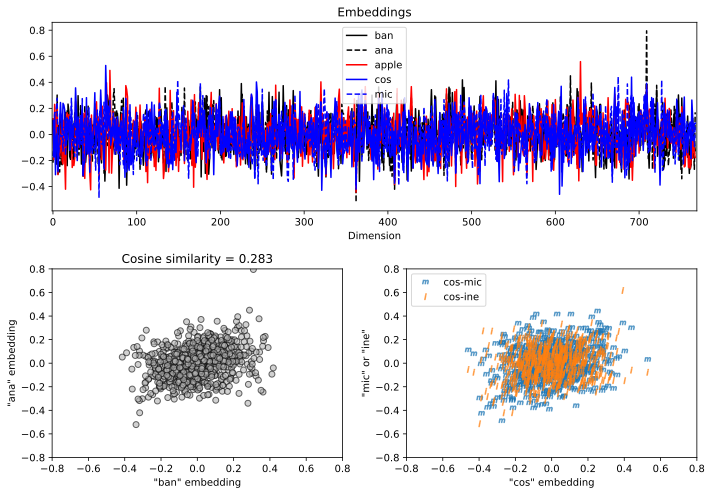

In [5]:
# setup the figure subplot geometry
fig = plt.figure(figsize = (10,7))
gs  = GridSpec(2,2)
ax0 = fig.add_subplot(gs[0,:])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1])

# plot the embeddings by dimension
colors = 'krb'
linestyles = ['-','--','-.',':']
for idx, word in enumerate([word1,word2,word3]):
  word_idx = gpt2_tokenizer.encode(word)
  for j in range(len(word_idx)):
    ax0.plot(gpt2_embeddings[word_idx[j], :],
             linestyle = linestyles[j],
             color = colors[idx],
             label = gpt2_tokenizer.decode(word_idx[j]))

ax0.set(xlabel = 'Dimension', title = 'Embeddings', xlim = [-1, gpt2_embeddings.shape[1]+1])
ax0.legend()

# cosine similarity between 'ban' and 'ana'
v1 = gpt2_embeddings[gpt2_tokenizer.encode('ban')]
v2 = gpt2_embeddings[gpt2_tokenizer.encode('ana')]
cossim = np.sum(v1*v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))

# plot embeddings by each other
ax1.plot(v1, v2, 'ko', markerfacecolor = [.7,.7,.7,.6])
ax1.set(xlim=[-.8,.8], ylim = [-.8,.8], xlabel = '"ban" embedding', ylabel = '"ana" embedding',
        title = f'Cosine similarity = {cossim:.3f}')

# plot the "cos" for two endings
for s in ['mic', 'ine']:
  # cosine similarity
  v1 = gpt2_embeddings[gpt2_tokenizer.encode('cos')].squeeze()
  v2 = gpt2_embeddings[gpt2_tokenizer.encode(s)].squeeze()
  cossim = np.sum(v1*v2) / (np.linalg.norm(v1)*np.linalg.norm(v2))

  # plot
  ax2.plot(v1, v2, marker=f'${s[0]}$', linestyle = 'none', alpha = .6, label = f'cos-{s}')

ax2.legend(fontsize = 10)
ax2.set(xlim = [-.8,.8], ylim = [-.8,.8], xlabel = '"cos" embedding', ylabel = '"mic" or "ine"')

plt.tight_layout()
plt.show()

## Target Word

In [6]:
word     = 'home'
word_tok = gpt2_tokenizer.encode(word)[0]
word_em  = gpt2_embeddings[word_tok]

cos_sims = []
for i, em in enumerate(gpt2_embeddings):
  cos_sim = (np.sum(word_em * em))/(np.linalg.norm(word_em) * np.linalg.norm(em))
  cos_sims.append(cos_sim.item())

In [7]:
cos_sims = np.array(cos_sims)

top20 = np.argsort(cos_sims)[-20:][::-1]
top20_words = [gpt2_tokenizer.decode([i]) for i in top20]
top20_cos_sims = cos_sims[top20]

plt.figure(figsize=(15,5))
plt.plot(range(len(cos_sims)), cos_sims, 'ko', markerfacecolor='w')
plt.xlim((-50, len(cos_sims)+50))
plt.scatter(top20, top20_cos_sims, marker='s', color='green', zorder=10)

plt.ylabel('Cosine Similarity')
plt.xlabel('Token Index')
plt.title(f'Cosine similarity to "{word}"')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [8]:
a = ''
for w, s in zip(top20_words, top20_cos_sims):
  print(f'"{w:^12}" with cosine similarity {s:.4f}')

"    home    " with cosine similarity 1.0000
"    home    " with cosine similarity 0.6972
"    Home    " with cosine similarity 0.6917
"    Home    " with cosine similarity 0.6253
"    HOME    " with cosine similarity 0.6078
"    homes   " with cosine similarity 0.5522
"    HOME    " with cosine similarity 0.5375
"   homers   " with cosine similarity 0.4794
"    Homes   " with cosine similarity 0.4781
" residences " with cosine similarity 0.4497
"    house   " with cosine similarity 0.4492
"  hometown  " with cosine similarity 0.4456
"    usr     " with cosine similarity 0.4450
"  homeowner " with cosine similarity 0.4424
"    homer   " with cosine similarity 0.4393
" homeowners " with cosine similarity 0.4335
"  residence " with cosine similarity 0.4300
"   House    " with cosine similarity 0.4181
"   house    " with cosine similarity 0.4101
"    away    " with cosine similarity 0.4081


## Vectorised Cosine Similarity

$$ Normalized\;v=\frac{v}{|v|} $$

$$ cossim = Normalized\;v[word] \cdot Normalized\;v.T$$

Thanks to that operation we don't need to use for loop, we use simple vector operation, the whole point of linear algebra.

Let's remember that when we take the dot product of a single word embedding
and the entire embedding matrix, we get a vector of shape
(embeddings.shape[0],) (or (1, embeddings.shape[0]) depending on broadcasting).
The highest value in this vector corresponds to the embedding that is most
similar to our word embedding due to:

$$
v_1 \cdot v_2 = \|v_1\| \|v_2\| \cos(\theta)
$$

If the embeddings are normalized ( \|v_1\| = \|v_2\| = 1 ), then:

$$
v_1 \cdot v_2 = \cos(\theta)
$$

Since \cos(\theta) is highest for parallel (most similar) vectors,
we just take argmax to get the index of the most similar word.

In [27]:
# normalize entire embedding matrix (in a new variable)
Enorm = gpt2_embeddings / np.linalg.norm(gpt2_embeddings, axis = 1, keepdims = True)

# cosine similarity matrices
seed = gpt2_tokenizer.encode([word])
cos_sims2 = Enorm[seed] @ Enorm.T

In [28]:
print(f'Size of for-loop version:   {cos_sims.shape}')
print(f'Size of vectorized version: {cos_sims2.shape}')

# remove singleton dimension
cos_sims2 = np.squeeze(cos_sims2)

print('\n** After squeezing:')
print(f'Size of for-loop version:   {cos_sims.shape}')
print(f'Size of vectorized version: {cos_sims2.shape}')

Size of for-loop version:   (50257,)
Size of vectorized version: (1, 1, 50257)

** After squeezing:
Size of for-loop version:   (50257,)
Size of vectorized version: (50257,)


Just checking

In [30]:
word

'home'

In [29]:
gpt2_tokenizer.decode([np.argmax(cos_sims2)])

'home'

Let's check if for-loop has same coverage as vectorized embeddings

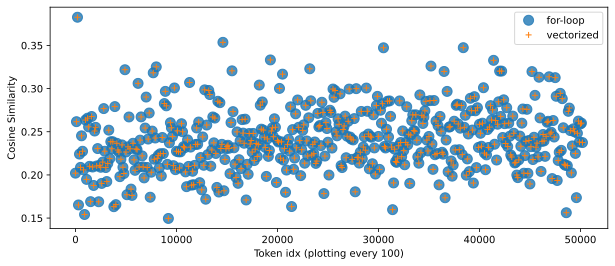

In [37]:
plt.figure(figsize = (10,4))
plt.plot(range(0, len(cos_sims), 100), cos_sims2[::100], 'o', label = 'for-loop', markersize = 10, alpha = .8)
plt.plot(range(0,len(cos_sims), 100), cos_sims2[::100], '+', label = 'vectorized')

plt.legend()
plt.gca().set(xlabel = 'Token idx (plotting every 100)', ylabel = 'Cosine Similarity')
plt.show()

Perfetto